In [7]:
import arviz as az
import matplotlib.pyplot as plt

# Load saved NetCDF InferenceData object
idata = az.from_netcdf("../data/hill_mmm_inference_data.nc")

print("InferenceData groups loaded successfully:")
print(idata)

InferenceData groups loaded successfully:
<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:             (chain: 2, draw: 1000)
│       Coordinates:
│         * chain               (chain) int64 16B 0 1
│         * draw                (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│       Data variables:
│           baseline_intercept  (chain, draw) float64 16kB ...
│           beta_promo          (chain, draw) float64 16kB ...
│           beta_meta           (chain, draw) float64 16kB ...
│           beta_tv             (chain, draw) float64 16kB ...
│           beta_google         (chain, draw) float64 16kB ...
│           K_meta              (chain, draw) float64 16kB ...
│           K_google            (chain, draw) float64 16kB ...
│           K_tv                (chain, draw) float64 16kB ...
│           S_meta              (chain, draw) float64 16kB ...
│           S_google            (chain, draw) float64 16kB ...
│           S_tv                (cha

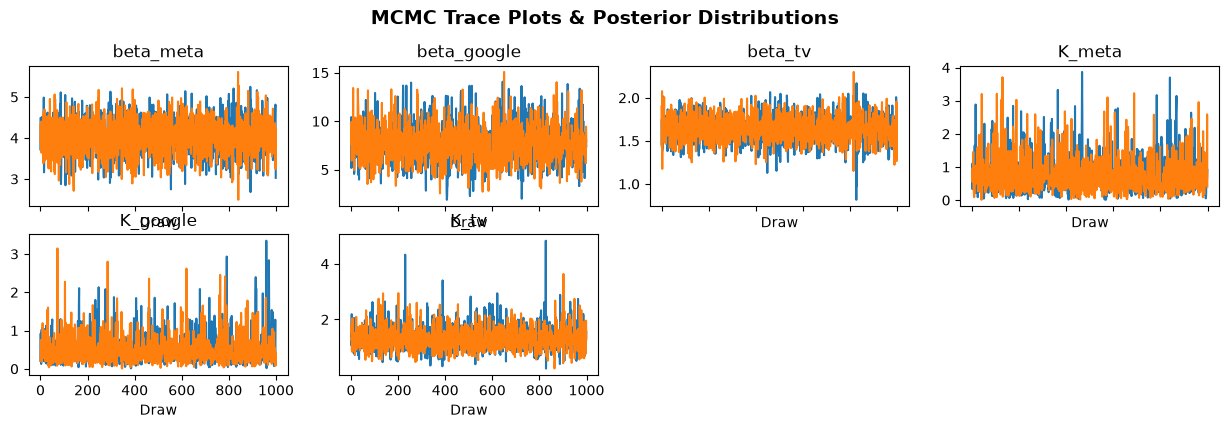

In [8]:
# Inspect trace convergence across chains for key channel betas and Hill parameters
az.plot_trace(
    idata, 
    var_names=["beta_meta", "beta_google", "beta_tv", "K_meta", "K_google", "K_tv"]
)
plt.suptitle("MCMC Trace Plots & Posterior Distributions", y=1.02, fontsize=14, fontweight='bold')
plt.show()

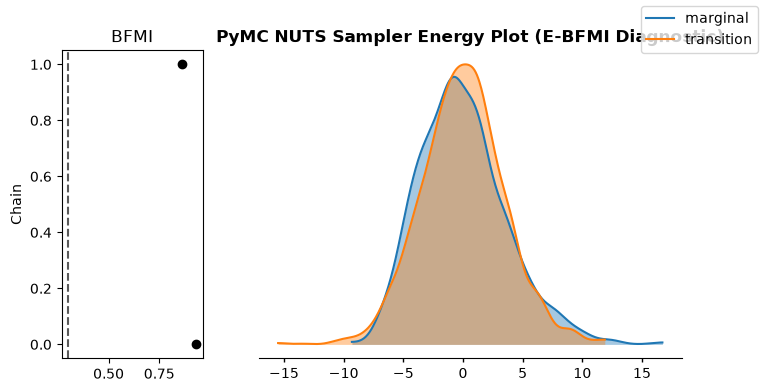

In [10]:
# Pass figure dimensions via figure_kwargs dictionary
az.plot_energy(
    idata, 
    figure_kwargs={"figsize": (8, 4)}
)
plt.title("PyMC NUTS Sampler Energy Plot (E-BFMI Diagnostic)", fontsize=12, fontweight='bold')
plt.show()

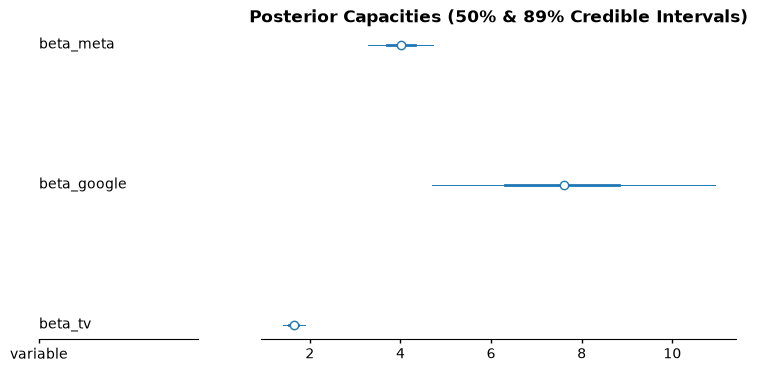

In [16]:
# Calibrated Channel Posterior Capacities (50% and 89% Credible Intervals)
az.plot_forest(
    idata, 
    var_names=["beta_meta", "beta_google", "beta_tv"],
    combined=True,
    ci_probs=(0.50, 0.89),
    figure_kwargs={"figsize": (9, 4)}
)
plt.title("Posterior Capacities (50% & 89% Credible Intervals)", fontsize=12, fontweight='bold')
plt.show()